
# Channel Prediction — Publication-Ready Notebook

This notebook compares several models for **wireless channel prediction**:

- GRU  
- LSTM  
- MLP  
- CNN  
- Transformer  
- Kalman Filter (KF) baseline  

It uses **two datasets** derived from the same underlying channel:
- **Clean (noise-free) channel**
- **Noisy channel** with additive white Gaussian noise (AWGN), e.g., SNR = 20 dB

The notebook will:

1. Load your `H2.mat` channel data.  
2. Convert the **real-valued** channel into a **complex baseband analytic signal** using the **Hilbert transform**.  
3. Prepare input–output sequences for prediction.  
4. Train all models and compute **MSE vs prediction horizon**.  
5. Plot:
   - **Figure 2**: True vs noisy vs predicted channel (complex plane).  
   - **Figure 3**: MSE vs prediction horizon for clean and noisy datasets.  
   - **Training vs validation (test) loss**.  
   - **Training vs validation (test) “accuracy”** (derived from loss).

> 🔧 You can tune hyperparameters (epochs, horizons, etc.) for your final paper.


In [1]:

import os
import random
import time
from pathlib import Path

import numpy as np
import scipy.io
from scipy.signal import hilbert
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from tqdm import tqdm

# ---------------- Configuration ----------------
OUT_DIR = Path("./outputs")
OUT_DIR.mkdir(exist_ok=True)

DATA_MAT_PATH = "./H2.mat"  # <-- change if needed

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# Experiment hyperparameters (adjust as needed)
EPOCHS = 10         # Increase for paper-quality results (e.g., 100–200)
BATCH_SIZE = 128
LR = 1e-3
PRED_HORIZONS = [1, 2, 5, 10, 15, 20, 30, 40]  # prediction steps (relative index)
INPUT_SEQ = 64      # input history length
PRED_LEN = max(PRED_HORIZONS)  # predict up to max horizon

def seed_all(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_all(SEED)


Device: cpu



## From real channel to complex analytic signal (Hilbert transform)

Your `H2.mat` file contains a **real-valued** channel `H` of shape `(1, N)`.

To obtain a **complex baseband representation** suitable for complex-plane plots
(like in Figure 2) we build the **analytic signal**:

\[
x_a(t) = x(t) + j \cdot \hat{x}(t)
\]

where \(\hat{x}(t)\) is the **Hilbert transform** of the real-valued signal \(x(t)\).

This yields a complex-valued sequence whose:
- real part = original real channel  
- imaginary part = quadrature component obtained via Hilbert transform  

We use this analytic signal as the **true channel**.


In [2]:

def load_complex_channel(mat_path=DATA_MAT_PATH):
    """Load H2.mat and return a 1D complex analytic signal using Hilbert transform."""
    if not os.path.exists(mat_path):
        raise FileNotFoundError(f"MAT file not found at {mat_path}")
    mat = scipy.io.loadmat(mat_path)
    if "H" not in mat:
        raise KeyError("MAT file does not contain variable 'H'")
    H = mat["H"].squeeze()   # shape (N,)
    print("Raw H shape:", H.shape, "dtype:", H.dtype)

    # If H is already complex, keep it; otherwise, make it analytic via Hilbert
    if np.iscomplexobj(H):
        Hc = H.astype(np.complex128)
        print("H is already complex.")
    else:
        analytic = hilbert(H)   # real -> complex analytic signal
        Hc = analytic.astype(np.complex128)
        print("Converted real H to complex analytic signal using Hilbert transform.")

    return Hc


In [3]:

def add_awgn(signal, snr_db):
    """Add complex AWGN to a complex signal."""
    signal = np.asarray(signal)
    assert np.iscomplexobj(signal)
    sig_power = np.mean(np.abs(signal) ** 2)
    sigma2 = sig_power / (10 ** (snr_db / 10))
    noise = np.sqrt(sigma2 / 2) * (
        np.random.randn(*signal.shape) + 1j * np.random.randn(*signal.shape)
    )
    return signal + noise


class ChannelDataset(Dataset):
    """Sliding-window dataset: inputs from one sequence, targets from another.

    input_seq: complex 1D array (measurement, possibly noisy)
    target_seq: complex 1D array (true channel)
    """
    def __init__(self, input_seq, target_seq, input_len=INPUT_SEQ, pred_len=PRED_LEN, scaler=None):
        input_seq = np.asarray(input_seq).astype(np.complex128)
        target_seq = np.asarray(target_seq).astype(np.complex128)
        assert len(input_seq) == len(target_seq), "Input and target sequences must have same length"
        self.input_len = input_len
        self.pred_len = pred_len

        N = len(input_seq)
        max_start = N - input_len - pred_len + 1
        if max_start <= 0:
            raise ValueError("Sequence too short for given INPUT_SEQ and PRED_LEN")

        X = np.array([input_seq[i : i + input_len] for i in range(max_start)])
        Y = np.array([target_seq[i + input_len : i + input_len + pred_len] for i in range(max_start)])

        # Split real & imag into 2 channels
        X = np.stack([X.real, X.imag], axis=-1)  # (samples, in_len, 2)
        Y = np.stack([Y.real, Y.imag], axis=-1)  # (samples, pred_len, 2)

        self.scaler = scaler
        if self.scaler is None:
            self.scaler = StandardScaler()
            nsamples, nin, nch = X.shape
            flat = X.reshape(-1, nch)
            self.scaler.fit(flat)
            X_scaled = self.scaler.transform(flat).reshape(nsamples, nin, nch)
            # Optionally scale targets as well (same scaler)
            Y_flat = Y.reshape(-1, nch)
            Y_scaled = self.scaler.transform(Y_flat).reshape(nsamples, pred_len, nch)
        else:
            nsamples, nin, nch = X.shape
            flat = X.reshape(-1, nch)
            X_scaled = self.scaler.transform(flat).reshape(nsamples, nin, nch)
            Y_flat = Y.reshape(-1, nch)
            Y_scaled = self.scaler.transform(Y_flat).reshape(nsamples, pred_len, nch)

        self.X = X_scaled.astype(np.float32)
        self.Y = Y_scaled.astype(np.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]


In [4]:

# ----------------- Models -----------------

class SeqGRU(nn.Module):
    def __init__(self, in_ch=2, hid=64, nlayers=2, pred_len=PRED_LEN):
        super().__init__()
        self.rnn = nn.GRU(input_size=in_ch, hidden_size=hid, num_layers=nlayers, batch_first=True)
        self.fc = nn.Linear(hid, in_ch * pred_len)
        self.pred_len = pred_len
        self.in_ch = in_ch

    def forward(self, x):
        # x: (B, T, C)
        out, _ = self.rnn(x)
        h = out[:, -1, :]
        y = self.fc(h)
        return y.view(-1, self.pred_len, self.in_ch)


class SeqLSTM(nn.Module):
    def __init__(self, in_ch=2, hid=64, nlayers=2, pred_len=PRED_LEN):
        super().__init__()
        self.rnn = nn.LSTM(input_size=in_ch, hidden_size=hid, num_layers=nlayers, batch_first=True)
        self.fc = nn.Linear(hid, in_ch * pred_len)
        self.pred_len = pred_len
        self.in_ch = in_ch

    def forward(self, x):
        out, _ = self.rnn(x)
        h = out[:, -1, :]
        y = self.fc(h)
        return y.view(-1, self.pred_len, self.in_ch)


class MLP(nn.Module):
    def __init__(self, in_ch=2, input_len=INPUT_SEQ, hid=256, pred_len=PRED_LEN):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_ch * input_len, hid),
            nn.ReLU(),
            nn.Linear(hid, hid),
            nn.ReLU(),
            nn.Linear(hid, pred_len * in_ch),
        )
        self.pred_len = pred_len
        self.in_ch = in_ch

    def forward(self, x):
        y = self.fc(x)
        return y.view(-1, self.pred_len, self.in_ch)


class TemporalCNN(nn.Module):
    def __init__(self, in_ch=2, pred_len=PRED_LEN, channels=[32, 64]):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_ch, channels[0], kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(channels[0], channels[1], kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(channels[1], pred_len * in_ch),
        )
        self.pred_len = pred_len
        self.in_ch = in_ch

    def forward(self, x):
        # (B, T, C) -> (B, C, T)
        x = x.permute(0, 2, 1)
        y = self.net(x)
        return y.view(-1, self.pred_len, self.in_ch)


class SimpleTransformer(nn.Module):
    def __init__(self, in_ch=2, hid=64, nhead=4, nlayers=2, pred_len=PRED_LEN):
        super().__init__()
        self.input_proj = nn.Linear(in_ch, hid)
        encoder_layer = nn.TransformerEncoderLayer(d_model=hid, nhead=nhead, batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=nlayers)
        self.fc = nn.Linear(hid, in_ch * pred_len)
        self.pred_len = pred_len
        self.in_ch = in_ch

    def forward(self, x):
        x = self.input_proj(x)
        x = self.encoder(x)
        h = x.mean(dim=1)
        y = self.fc(h)
        return y.view(-1, self.pred_len, self.in_ch)


# Simple Kalman filter baseline (per real/imag channel treated independently)
class SimpleKalman:
    def __init__(self, R=1e-2, Q=1e-4):
        self.R = R
        self.Q = Q
        self.x = None
        self.P = None

    def reset(self, x0=None):
        if x0 is None:
            self.x = np.array([0.0, 0.0])
        else:
            self.x = np.array([x0.real, x0.imag])
        self.P = np.eye(2)

    def update(self, z):
        zvec = np.array([z.real, z.imag])
        xpred = self.x
        Ppred = self.P + self.Q * np.eye(2)
        S = Ppred + self.R * np.eye(2)
        K = Ppred @ np.linalg.inv(S)
        self.x = xpred + K @ (zvec - xpred)
        self.P = (np.eye(2) - K) @ Ppred
        return self.x[0] + 1j * self.x[1]


In [5]:

# ----------------- Training & evaluation helpers -----------------

def train_one_epoch(model, loader, optimizer, lossfn):
    model.train()
    running = 0.0
    n = 0
    for xb, yb in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        optimizer.zero_grad()
        out = model(xb)
        loss = lossfn(out, yb)
        loss.backward()
        optimizer.step()
        running += loss.item() * xb.size(0)
        n += xb.size(0)
    return running / n


def evaluate_model(model, loader, lossfn):
    model.eval()
    running = 0.0
    n = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            out = model(xb)
            loss = lossfn(out, yb)
            running += loss.item() * xb.size(0)
            n += xb.size(0)
    return running / n


def compute_mse_per_horizon(model, dataset, horizons=PRED_HORIZONS):
    loader = DataLoader(dataset, batch_size=256, shuffle=False)
    model.eval()
    mse_dict = {h: 0.0 for h in horizons}
    count = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            out = model(xb)  # (B, pred_len, 2)
            out_np = out.cpu().numpy()
            y_np = yb.cpu().numpy()
            for h in horizons:
                idx = h - 1
                if idx < out_np.shape[1]:
                    err = (out_np[:, idx, :] - y_np[:, idx, :]) ** 2
                    mse = err.mean()
                    mse_dict[h] += mse * out_np.shape[0]
            count += out_np.shape[0]
    for h in horizons:
        mse_dict[h] /= count
    return mse_dict


def kalman_predict_sequence(seq_complex, pred_len=PRED_LEN):
    kf = SimpleKalman(R=1e-2, Q=1e-4)
    kf.reset(seq_complex[0])
    for z in seq_complex:
        _ = kf.update(z)
    last = kf.x
    preds = [last[0] + 1j * last[1]] * pred_len
    return np.array(preds)


In [6]:

# ----------------- Main experiment routine -----------------

def run_experiment(mat_path=DATA_MAT_PATH, snr_db=None, outprefix="clean"):
    """Train all models on clean/noisy data and compute MSE vs prediction horizon."""
    channel = load_complex_channel(mat_path)  # complex 1D
    N = min(len(channel), 30000)  # limit for quick runs
    channel = channel[:N]

    if snr_db is None:
        seq_in = channel
        seq_target = channel
        print("Running experiment on CLEAN data.")
    else:
        seq_target = channel
        seq_in = add_awgn(channel, snr_db)
        print(f"Running experiment on NOISY data (SNR={snr_db} dB).")

    # Train/val/test split
    train_frac = 0.7
    val_frac = 0.15
    ntrain = int(N * train_frac)
    nval = int(N * val_frac)
    train_in = seq_in[:ntrain]
    val_in = seq_in[ntrain : ntrain + nval]
    test_in = seq_in[ntrain + nval :]

    train_target = seq_target[:ntrain]
    val_target = seq_target[ntrain : ntrain + nval]
    test_target = seq_target[ntrain + nval :]

    # Build datasets
    train_ds = ChannelDataset(train_in, train_target, input_len=INPUT_SEQ, pred_len=PRED_LEN)
    val_ds = ChannelDataset(val_in, val_target, input_len=INPUT_SEQ, pred_len=PRED_LEN, scaler=train_ds.scaler)
    test_ds = ChannelDataset(test_in, test_target, input_len=INPUT_SEQ, pred_len=PRED_LEN, scaler=train_ds.scaler)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

    models = {
        "GRU": SeqGRU(in_ch=2, hid=64, nlayers=2, pred_len=PRED_LEN).to(DEVICE),
        "LSTM": SeqLSTM(in_ch=2, hid=64, nlayers=2, pred_len=PRED_LEN).to(DEVICE),
        "MLP": MLP(in_ch=2, input_len=INPUT_SEQ, hid=256, pred_len=PRED_LEN).to(DEVICE),
        "CNN": TemporalCNN(in_ch=2, pred_len=PRED_LEN).to(DEVICE),
        "Transformer": SimpleTransformer(in_ch=2, hid=64, nhead=4, nlayers=2, pred_len=PRED_LEN).to(DEVICE),
    }

    results = {}
    lossfn = nn.MSELoss()

    for name, model in models.items():
        print(f"\nTraining {name} on {outprefix} data...")
        optimizer = torch.optim.Adam(model.parameters(), lr=LR)
        history = {"train_loss": [], "val_loss": []}
        best_val = float("inf")

        for epoch in range(1, EPOCHS + 1):
            tr_loss = train_one_epoch(model, train_loader, optimizer, lossfn)
            val_loss = evaluate_model(model, val_loader, lossfn)
            history["train_loss"].append(tr_loss)
            history["val_loss"].append(val_loss)

            if val_loss < best_val:
                best_val = val_loss
                torch.save(model.state_dict(), OUT_DIR / f"{outprefix}_{name}_best.pth")

            if epoch % max(1, EPOCHS // 10) == 0 or epoch == 1:
                print(f"Epoch {epoch}/{EPOCHS} - train: {tr_loss:.6e}, val: {val_loss:.6e}")

        # Reload best model
        model.load_state_dict(torch.load(OUT_DIR / f"{outprefix}_{name}_best.pth"))

        # Compute test loss
        test_loss = evaluate_model(model, test_loader, lossfn)

        # MSE vs horizon
        mse_h = compute_mse_per_horizon(model, test_ds, horizons=PRED_HORIZONS)

        # Save history & per-horizon MSE
        pd.DataFrame(history).to_csv(OUT_DIR / f"{outprefix}_{name}_history.csv", index=False)
        pd.DataFrame.from_dict(mse_h, orient="index", columns=["mse"]).to_csv(
            OUT_DIR / f"{outprefix}_{name}_mse_h.csv"
        )

        results[name] = {"test_loss": test_loss, "mse_h": mse_h, "history": history}
        print(f"{name} test loss: {test_loss:.6e}")

    # Kalman filter per-horizon MSE on test sequence
    print("\nRunning Kalman filter baseline...")
    k_mse = {h: 0.0 for h in PRED_HORIZONS}
    count = 0
    L = INPUT_SEQ
    for i in range(len(test_target) - L - PRED_LEN + 1):
        window = test_in[i : i + L]
        true_future = test_target[i + L : i + L + PRED_LEN]
        preds = kalman_predict_sequence(window, pred_len=PRED_LEN)
        for h in PRED_HORIZONS:
            k_mse[h] += np.mean(np.abs(preds[h - 1] - true_future[h - 1]) ** 2)
        count += 1
    for h in PRED_HORIZONS:
        k_mse[h] /= count

    results["Kalman"] = {"test_loss": None, "mse_h": k_mse, "history": None}
    pd.DataFrame.from_dict(k_mse, orient="index", columns=["mse"]).to_csv(
        OUT_DIR / f"{outprefix}_Kalman_mse_h.csv"
    )

    # Save aggregate summary
    summary_rows = []
    for name, info in results.items():
        for h, v in info["mse_h"].items():
            summary_rows.append({"model": name, "horizon": h, "mse": v})
    summary_df = pd.DataFrame(summary_rows)
    summary_df.to_csv(OUT_DIR / f"{outprefix}_summary_mse.csv", index=False)

    # -------- Plot Figure 3 style: MSE vs prediction horizon --------
    plt.figure(figsize=(6, 4))
    for name, info in results.items():
        mse_vec = np.array([info["mse_h"][h] for h in PRED_HORIZONS])
        plt.plot(PRED_HORIZONS, 10 * np.log10(mse_vec + 1e-12), marker="o", label=name)
    plt.xlabel("Prediction horizon (steps)")
    plt.ylabel("MSE (dB)")
    plt.title(f"Prediction error vs horizon ({outprefix})")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"{outprefix}_figure3.png", dpi=300)

    # -------- Plot Figure 2 style: true vs noisy vs GRU prediction --------
    # Use a single sample from test_ds
    sample_x, sample_y = test_ds[0]
    # rebuild complex true seq segment (input+target)
    true_segment = (np.concatenate([sample_x, sample_y], axis=0)[:, 0]
                    + 1j * np.concatenate([sample_x, sample_y], axis=0)[:, 1])

    if snr_db is None:
        noisy_segment = true_segment.copy()
    else:
        noisy_segment = add_awgn(true_segment, snr_db)

    # GRU prediction for the future part only
    gru_model = models["GRU"]
    gru_model.eval()
    with torch.no_grad():
        xb_t = torch.tensor(sample_x).unsqueeze(0).to(DEVICE)
        pred = gru_model(xb_t).cpu().numpy().squeeze()  # (PRED_LEN, 2)
    pred_complex_future = pred[:, 0] + 1j * pred[:, 1]
    pred_segment = np.concatenate([
        sample_x[:, 0] + 1j * sample_x[:, 1],
        pred_complex_future
    ])

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(true_segment.real, true_segment.imag, "-k", linewidth=1.5, label="True channel")
    plt.plot(noisy_segment.real, noisy_segment.imag, "x-", linewidth=0.7, label="Noisy channel")
    plt.xlabel("Real axis")
    plt.ylabel("Imaginary axis")
    plt.title("a) True vs noisy")
    plt.grid(True)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(true_segment.real, true_segment.imag, "-k", linewidth=1.5, label="True channel")
    plt.plot(pred_segment.real, pred_segment.imag, "-g", linewidth=1.2, label="Predicted (GRU)")
    plt.xlabel("Real axis")
    plt.ylabel("Imaginary axis")
    plt.title("b) True vs predicted (GRU)")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.savefig(OUT_DIR / f"{outprefix}_figure2.png", dpi=300)

    return results



## Training vs validation (test) loss and accuracy

We define a simple **accuracy-like metric** for regression:

\[
\text{accuracy} = \frac{1}{1 + \text{MSE}}
\]

This is a monotonic transformation of the loss and lies in (0, 1).  
It is not a classification accuracy, but it gives an intuitive “higher is better” curve.


In [7]:

def plot_loss_curves(history_dict, title="Training vs validation loss"):
    plt.figure(figsize=(6, 4))
    plt.plot(history_dict["train_loss"], label="Train loss")
    plt.plot(history_dict["val_loss"], label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE loss")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_accuracy_curves(history_dict, title="Training vs validation accuracy"):
    train_loss = np.array(history_dict["train_loss"])
    val_loss = np.array(history_dict["val_loss"])
    train_acc = 1.0 / (1.0 + train_loss)
    val_acc = 1.0 / (1.0 + val_loss)
    plt.figure(figsize=(6, 4))
    plt.plot(train_acc, label="Train accuracy")
    plt.plot(val_acc, label="Validation accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (1 / (1 + MSE))")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()



## Run the experiments

> ⚠️ For quick testing, keep `EPOCHS` small (e.g., 10–20).  
> For final paper-quality results, increase `EPOCHS` to 100–200.

The following cell will:

- Run experiments on **clean** data.  
- Run experiments on **noisy** data (e.g. SNR = 20 dB).  
- Save all CSVs and figures in the `./outputs/` folder.  
- Return a `results` dictionary for further plotting.


Raw H shape: (2688000,) dtype: float64
Converted real H to complex analytic signal using Hilbert transform.
Running experiment on CLEAN data.

Training GRU on clean data...
Epoch 1/10 - train: 5.140984e-01, val: 5.102082e-02
Epoch 2/10 - train: 1.434384e-02, val: 3.798874e-03
Epoch 3/10 - train: 4.860211e-03, val: 4.763838e-03
Epoch 4/10 - train: 4.009901e-03, val: 2.886651e-03
Epoch 5/10 - train: 3.586811e-03, val: 2.566512e-03
Epoch 6/10 - train: 3.200200e-03, val: 2.426149e-03
Epoch 7/10 - train: 2.916094e-03, val: 2.284004e-03
Epoch 8/10 - train: 2.615104e-03, val: 1.955848e-03
Epoch 9/10 - train: 2.427157e-03, val: 2.125402e-03
Epoch 10/10 - train: 2.269772e-03, val: 1.975880e-03
GRU test loss: 3.031280e-03

Training LSTM on clean data...
Epoch 1/10 - train: 5.882419e-01, val: 2.495581e-01
Epoch 2/10 - train: 4.076442e-01, val: 1.436918e-02
Epoch 3/10 - train: 9.390291e-03, val: 4.354332e-03
Epoch 4/10 - train: 4.619927e-03, val: 2.957140e-03
Epoch 5/10 - train: 3.793733e-03, val:

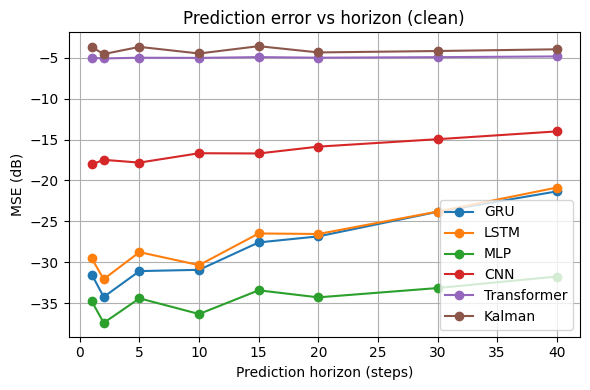

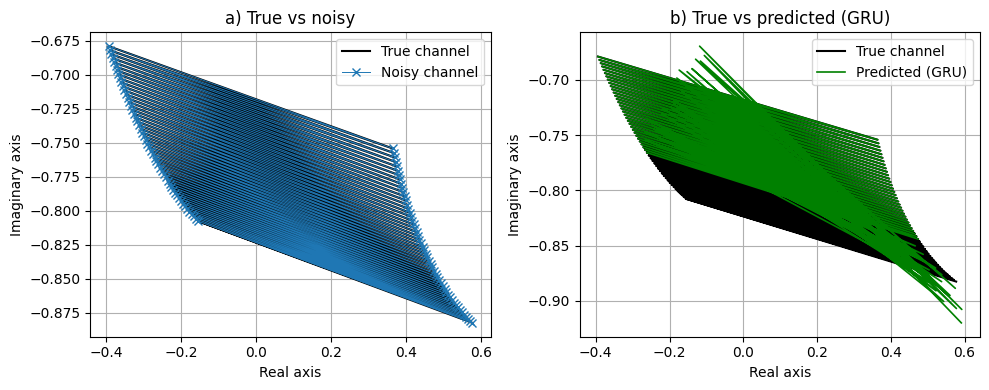

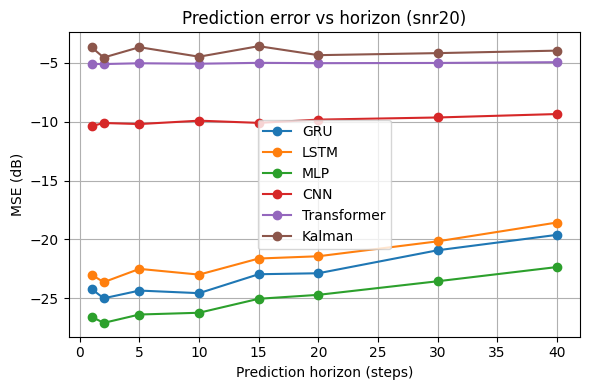

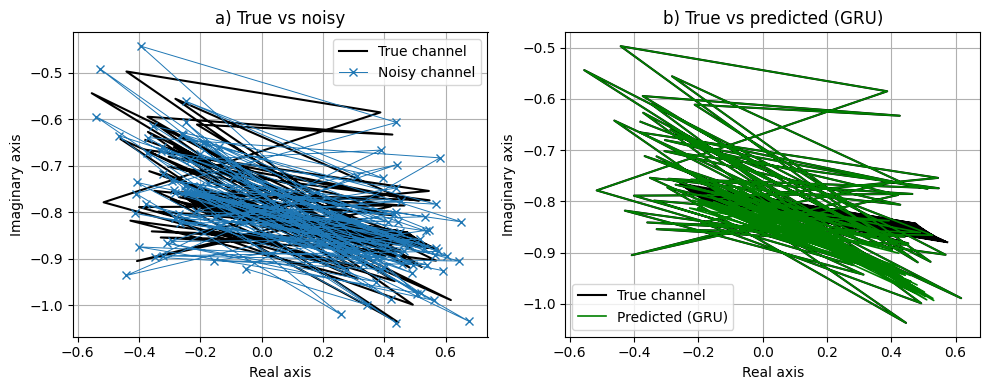

In [8]:

# Uncomment to run full experiments.
# This may take several minutes depending on EPOCHS and your hardware.

res_clean = run_experiment(DATA_MAT_PATH, snr_db=None, outprefix="clean")
res_noisy = run_experiment(DATA_MAT_PATH, snr_db=20, outprefix="snr20")

print("Notebook ready. To run experiments, uncomment the lines above and execute this cell.")



## Example: Plot training vs validation loss and accuracy for GRU

After running `run_experiment`, you can visualize GRU’s learning curves as follows:


In [9]:

# Example usage AFTER you have run the experiments:

# Example for clean GRU:
# gru_hist_clean = res_clean["GRU"]["history"]
# plot_loss_curves(gru_hist_clean, title="GRU (clean) - Loss")
# plot_accuracy_curves(gru_hist_clean, title="GRU (clean) - Accuracy")

# Example for noisy GRU:
# gru_hist_noisy = res_noisy["GRU"]["history"]
# plot_loss_curves(gru_hist_noisy, title="GRU (noisy) - Loss")
# plot_accuracy_curves(gru_hist_noisy, title="GRU (noisy) - Accuracy")
